# AMI Deconvolutions


In [1]:
import os
import jax
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [ ]:
# cache = "/Users/mcha5804/code/amigo_files/"
cache = "/Volumes/max/data/amigo_files/"
data_path = "/Users/mcha5804/JWST/NGC1068/calslope/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_state/")

state = np.load(
    os.path.join(model_cache, "ode/test_state.npy"), allow_pickle=True
).item()

EXP_TYPE = "NIS_AMI"
FILTERS = ["F480M", "F430M", "F380M"]  # , "F277W"]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [3]:
# Build the ramp model
n_latent = 6
keys = jr.split(jr.PRNGKey(0), 3)
encoder = amigo.latent_ode_models.LatentEncoder(
    n_latent=n_latent, width=6, depth=2, key=keys[0], pools=[0, 1]
)
latent_ode = amigo.latent_ode_models.LatentODE(
    n_latent=n_latent, width=3, depth=2, key=keys[1]
)
decoder = amigo.latent_ode_models.LatentDecoder(
    n_latent=n_latent, depth=3, key=keys[2], up_samples=[1, 2], out_channels=2
)

# ramp = LatentODERamp(encoder=encoder, latent_ode=latent_ode, decoder=decoder)
ode_ramp = amigo.latent_ode_models.GainDiffusionRamp(
    encoder=encoder, latent_ode=latent_ode, decoder=decoder
)

In [4]:
# # model_cache = "/Volumes/mcha5804/data/JWST/model_cache/"
# model_cache = "/Users/mcha5804/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/PyCharm/jwst/io/arrays/"
# # model_cache = "/mnt/Z/data/JWST/model_cache/"
# init_state_cache = model_cache + "init_states/"
# fisher_cache = model_cache + "fishers/"
# # gif_dir = "/Users/mcha5804/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/PyCharm/jwst/io/gifs/"
# # reconstructions_dir = "/Users/mcha5804/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/PyCharm/jwst/io/reconstructions/"

# final_states = [
#     np.load(model_cache + f"new_top_models 2/state_{i}.npy", allow_pickle=True)[()]
#     # for i in ["36", "63", "112", "120"]
#     for i in ["84", "125"]
# ]

# final_state = final_states[1]

# # final_state = np.load(model_cache + "odes/ode_state.npy", allow_pickle=True).item()

# width = final_state.pop("width")
# depth = final_state.pop("depth")
# _ = final_state.pop("lr")
# _ = final_state.pop("rand_size")

# EXP_TYPE = "NIS_AMI"
# FILTERS = ["F480M", "F430M", "F380M"]  # , "F277W"]

# # Bind file path, type and exposure type
# file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
#     # "/Users/mcha5804/JWST/ERS1373/calgrps/",
#     data_path,
#     "calslope",
#     EXP_TYPE=EXP_TYPE,
#     FILTER=filters,
#     **kwargs,
# )

# Loading in data

In [5]:
files = file_fn(data_path)

# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# print(f"{len(sci_files)} Science Files:")
# for f in sci_files:
#     # print(f[0].header["TARGPROP"], f[0].header["NGROUPS"], f["SLOPE"].data.shape, f[0].header["FILTER"])
#     print(f"\
#         TARG: {f[0].header['TARGPROP']}\
#         NGROUPS: {f[0].header['NGROUPS']}\
#         FILTER: {f[0].header['FILTER']}\
#         shape: {f['SLOPE'].data.shape}\
#     ")

# print()
# print(f"{len(cal_files)} Calibrator Files:")
# for f in cal_files:
#     print(f"\
#         TARG: {f[0].header['TARGPROP']}\
#         NGROUPS: {f[0].header['NGROUPS']}\
#         FILTER: {f[0].header['FILTER']}\
#         shape: {f['SLOPE'].data.shape}\
#     ")

# dorito.misc.truncate_files(cal_files, 5)
dorito.misc.truncate_files(sci_files, 3)

In [6]:
from dorito import misc
from dorito import models


def build_resolved_model(
    cal_files,
    sci_files,
    state,
    extra_priors: dict = {"log_distribution": None, "spectral_coeffs": None},
    ramp_model=None,
    width: int = None,
    depth: int = None,
    separate_fits: bool = False,
    modeller=None,
    cal_fit=amigo.model_fits.PointFit,
    sci_fit=None,
    optics=None,
    **model_kwargs,
):
    """
    Constructing the model.
    """

    if ramp_model is None:
        if width is None or depth is None:
            raise ValueError(
                "If ramp_model is not provided, width and depth must be specified"
            )

    if ramp_model is not None and (width is not None or depth is not None):
        raise ValueError(
            "If ramp_model is provided, width and depth must not be specified"
        )

    # Ramp
    if ramp_model is None:
        layers, pooling_layer = amigo.ramp_models.build_pooled_layers(
            width=width,
            depth=depth,
            pooling="avg",
        )
        ramp_model = amigo.ramp_models.MinimalConv(layers, pooling_layer)

    # if cal_fit is None:

    if sci_fit is None:
        # sci_fit = model_fits.DynamicResolvedFit()
        sci_fit = amigo.model_fits.PointFit

    if optics is None:
        optics = amigo.optical_models.AMIOptics(
            radial_orders=4,
            distortion_orders=3,
        )

    if modeller is None:
        modeller = models.ResolvedAmigoModel

    # Generate calibrator and science fits separately
    cal_fits = [cal_fit(file) for file in cal_files]
    sci_fits = [sci_fit(file) for file in sci_files]

    # initialising model parameters
    sci_params = amigo.files.initialise_params(sci_files, sci_fits, optics)
    cal_params = amigo.files.initialise_params(cal_files, cal_fits, optics)
    cal_params["Teffs"] = amigo.search_Teffs.get_Teffs(cal_files)

    # populating params with priors of extra parameters
    for param in extra_priors.keys():
        # skip wavelets as this is handled in the
        # WaveletModel class __init__ method
        if param == "wavelets":
            model_kwargs["wavelets"] = extra_priors[param]
            model_kwargs["exposures"] = [*cal_fits, *sci_fits]
            continue

        extra_param_dict = {}
        for exp in sci_fits:
            extra_param_dict[exp.get_key(param)] = extra_priors[param]
        sci_params[param] = extra_param_dict

    # combining calibrator and science
    params = misc.combine_param_dicts(cal_params, sci_params)

    # setting up filters
    filters = {}
    for filt in list(set([fit.filter for fit in [*sci_fits, *cal_fits]])):
        filters[filt] = amigo.misc.calc_throughput(filt, nwavels=9)

    # initialising model
    model = modeller(
        params,
        optics=optics,
        ramp=ramp_model,
        detector=amigo.detector_models.SUB80Detector(),
        read=amigo.read_models.ReadModel(),
        filters=filters,
        **model_kwargs,
    )

    model = amigo.misc.populate_from_state(model, state)

    # returning calibrator and science exposures separately
    if separate_fits:
        return model, params, cal_fits, sci_fits

    # otherwise, return all exposures together
    else:
        fits = [*cal_fits, *sci_fits]
        return model, params, fits

In [ ]:
source_size = 98
shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
wavelets = dorito.build_model.wavelet_prior(source_size)

model, params, cal_fits, sci_fits = build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    # [cal_files[-1]],
    # [sci_files[-1]],
    cal_files,
    sci_files,
    state=state,
    # width=width,
    # depth=depth,
    ramp_model=ode_ramp,
    extra_priors={
        # "wavelets": shearlets,
        # "wavelets": wavelets,
        "log_distribution": np.log10(
            np.ones((source_size, source_size)) / source_size**2
        ),
        "spectral_coeffs": np.array([1.0, 0.0]),
    },
    # shearletSystem=shearletSystem,
    sci_fit=dorito.model_fits.ResolvedFit,
    # sci_fit=dorito.model_fits.WaveletFit(),
    separate_fits=True,
)
fits = [*cal_fits, *sci_fits]

# init_state = np.load(init_state_cache + "NGC1068/F480Mone.npy", allow_pickle=True)[()]

# for p in [
#     "positions",
#     "fluxes",
#     "aberrations"
#     ]:
#     params[p] = init_state[p]

# model = model.set("params", params)
model = model.set("FF", np.ones_like(model.FF))

No Teff found for NGC1068, defaulting to 4500K


/Users/mcha5804/miniconda3/envs/amigo/lib/python3.11/site-packages/astroquery/simbad/core.py:135: UserWarning: Warning: The script line number 2 raised an error (recorded in the `errors` attribute of the result table): 'M-77' this identifier has an incorrect format for catalogs: 	M : Messier Objects 	M (
  warnings.warn("Warning: The script line number %i raised "


In [8]:
for fs in [sci_fits, cal_fits]:
    print(f"{len(fs)} Files:")
    for f in fs:

        img = np.where(f.badpix, np.nan, f.ramp[-1])

        print(
            f"\
            TARG: {f.star}\
            FILTER: {f.filter}\
            NGROUPS: {f.ngroups}\
            PEAK: {int(np.nanmax(img))}, {np.nanmax(img) / 2**16 :.1%} sat. \
        "
        )
    print()

for fs in [sci_fits, cal_fits]:
    print(f"{len(fs)} Files:")

    for f in fs:
        grps = np.array([np.where(f.badpix, np.nan, grp) for grp in f.ramp])
        top = grps[-1]
        print(
            f"\
            TARG: {f.star}\
            FILTER: {f.filter}\
            NGROUPS: {f.ngroups}\
            PEAK: {int(np.nanmax(top))}, {np.nanmax(top) / 2**16 :.1%} sat. \
        "
        )

        for i, grp in enumerate(grps):
            print(
                f"GROUP {i}, PEAK: {int(np.nanmax(grp))}, {np.nanmax(grp) / 2**16 :.1%} sat."
            )
        # print(f"PEAK: {int(np.nanmax(img))}, {np.nanmax(img) / 2**16 :.1%} sat.")
        print()

1 Files:
            TARG: NGC1068            FILTER: F480M            NGROUPS: 3            PEAK: 24724, 37.7% sat.         

1 Files:
            TARG: HD17130            FILTER: F480M            NGROUPS: 6            PEAK: 12968, 19.8% sat.         

1 Files:
            TARG: NGC1068            FILTER: F480M            NGROUPS: 3            PEAK: 24724, 37.7% sat.         
GROUP 0, PEAK: 15113, 23.1% sat.
GROUP 1, PEAK: 19284, 29.4% sat.
GROUP 2, PEAK: 24724, 37.7% sat.

1 Files:
            TARG: HD17130            FILTER: F480M            NGROUPS: 6            PEAK: 12968, 19.8% sat.         
GROUP 0, PEAK: 12496, 19.1% sat.
GROUP 1, PEAK: 12511, 19.1% sat.
GROUP 2, PEAK: 12627, 19.3% sat.
GROUP 3, PEAK: 12740, 19.4% sat.
GROUP 4, PEAK: 12854, 19.6% sat.
GROUP 5, PEAK: 12968, 19.8% sat.



F480M
F480M


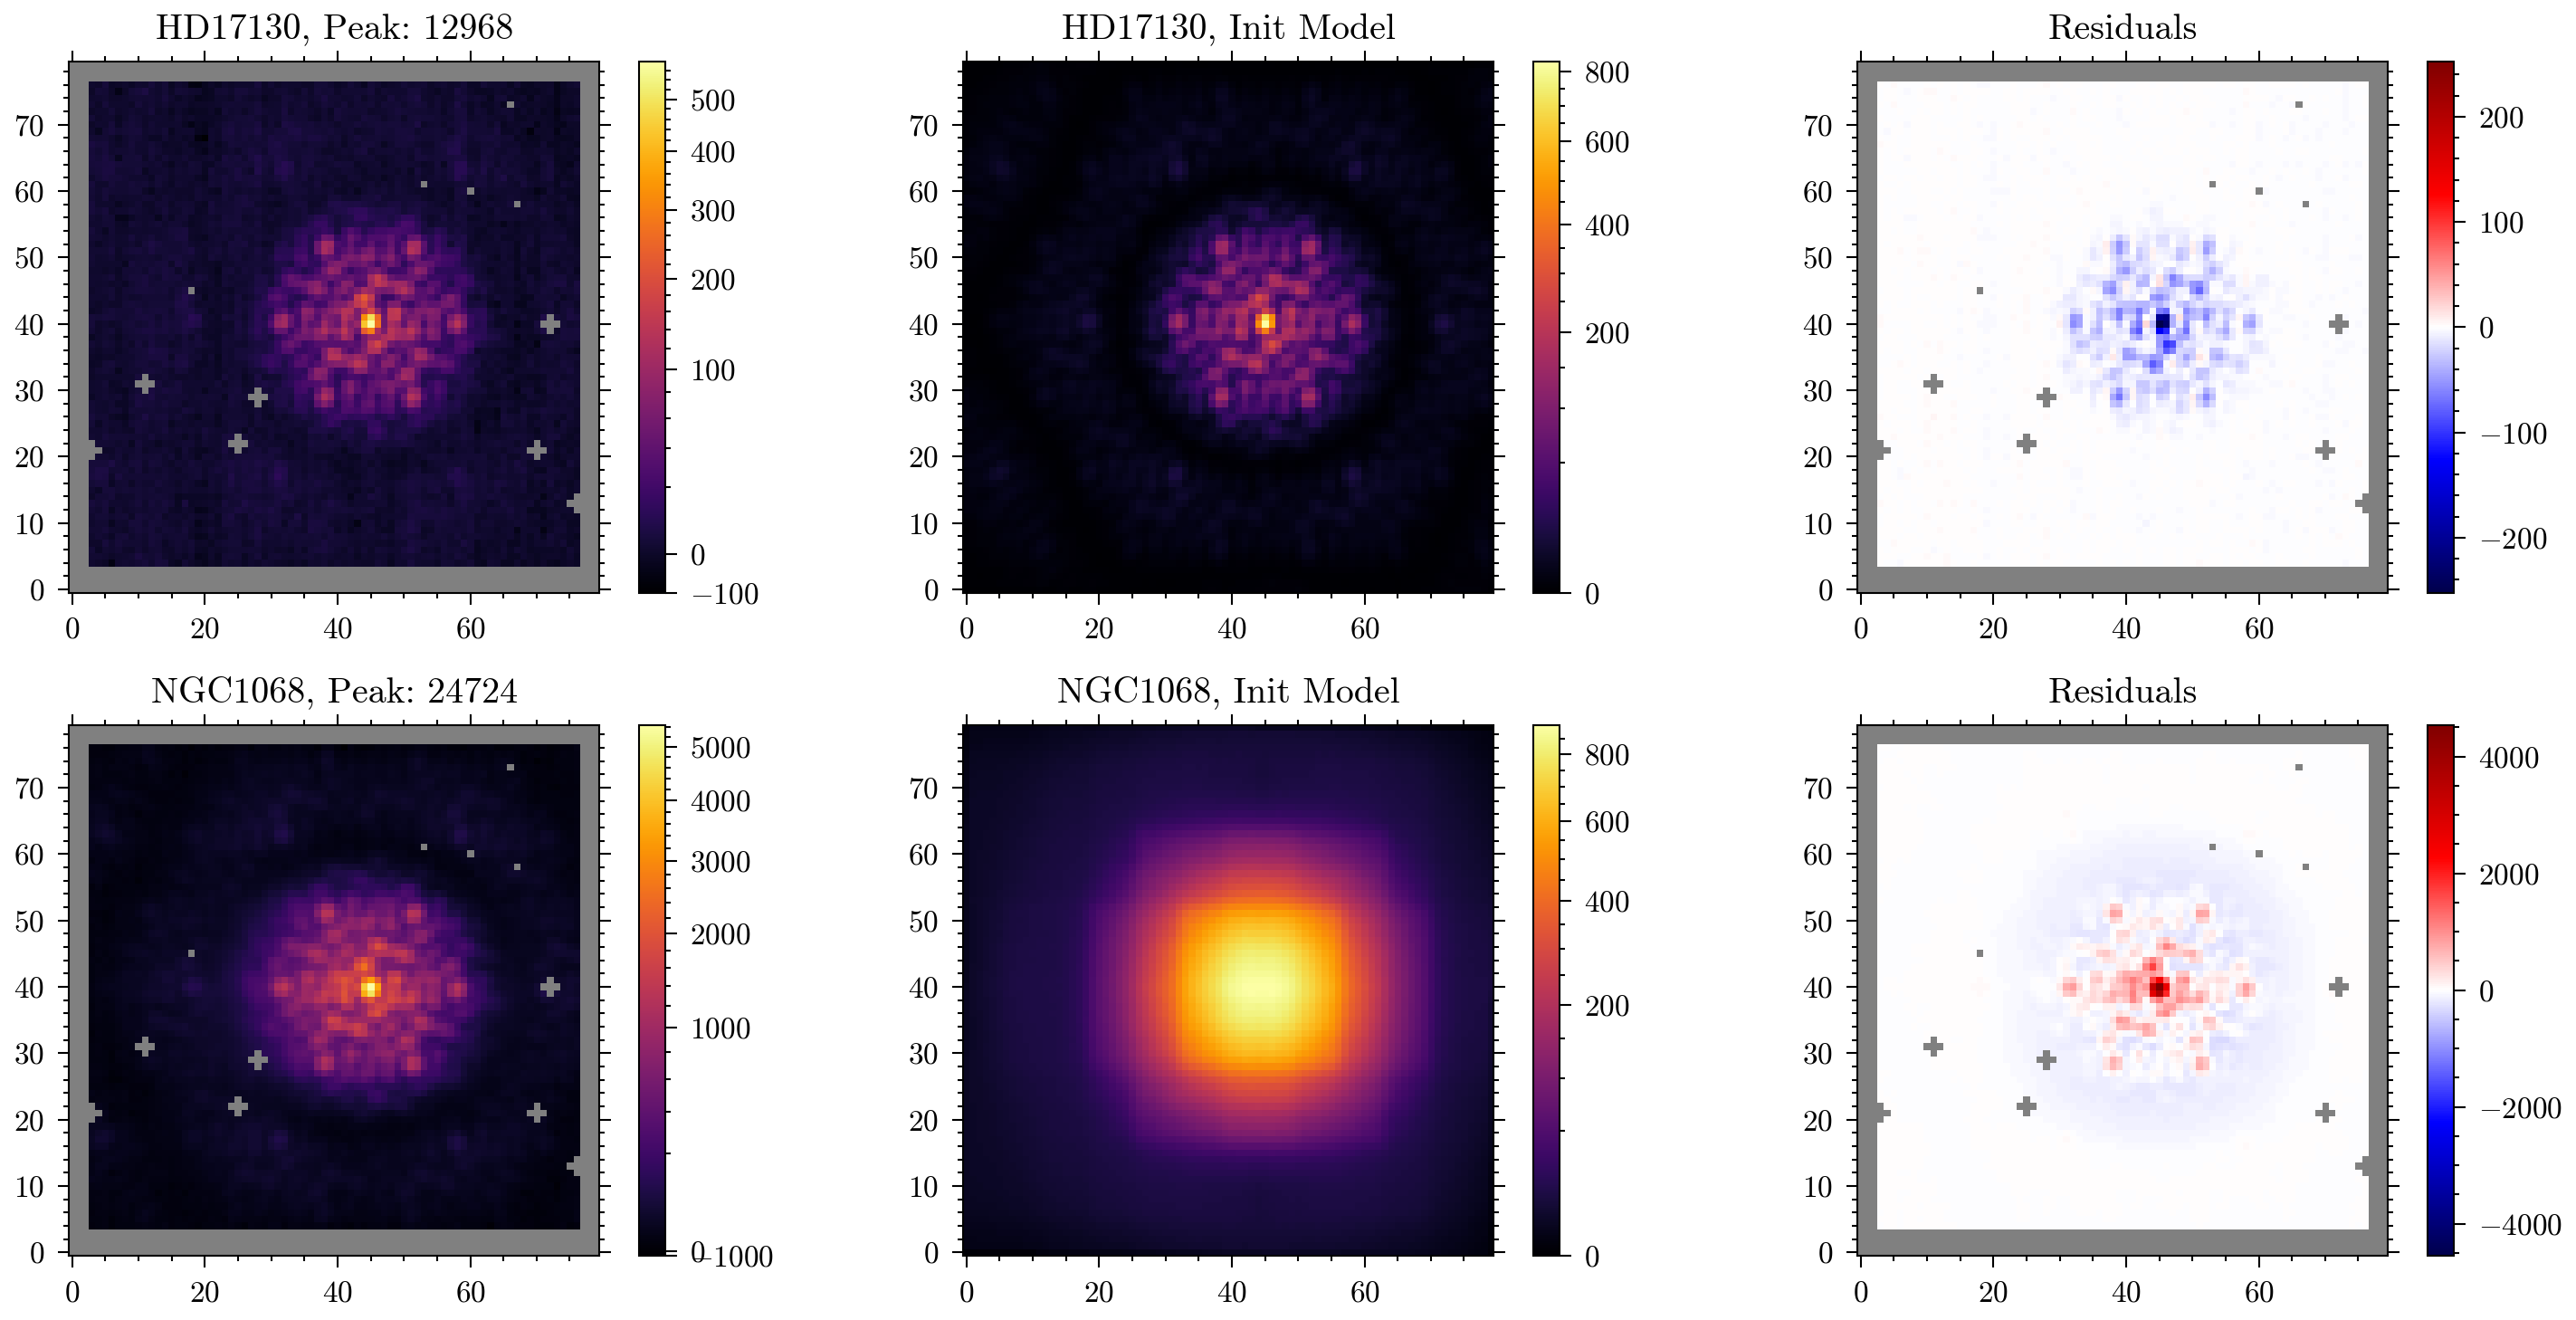

In [9]:
plt.subplots(2, 3, figsize=(10, 5))

for i in [0, -1]:
    fit = fits[i]
    slope = fits[i].slopes[-1]
    ramp = fits[i].ramp[-1]
    badpix = fits[i].badpix
    ppcount = np.nanmax(np.where(badpix, np.nan, ramp))

    print(fit.filter)

    x = np.where(badpix, np.nan, slope)
    plt.subplot(2, 3, 3 * abs(i) + 1)
    plt.imshow(x, cmap=inferno, norm=mpl.colors.PowerNorm(0.5))
    plt.title(f"{fits[i].star}, Peak: {int(ppcount)}")
    plt.colorbar()

    init_slopes = fit(model)
    plt.subplot(2, 3, 3 * abs(i) + 2)
    plt.imshow(init_slopes[-1], cmap=inferno, norm=mpl.colors.PowerNorm(0.5))
    plt.title(f"{fits[i].star}, Init Model")
    plt.colorbar()

    plt.subplot(2, 3, 3 * abs(i) + 3)
    plt.imshow(x - init_slopes[-1], cmap=seismic, norm=mpl.colors.CenteredNorm())
    plt.title(f"Residuals")
    plt.colorbar()


plt.tight_layout()
plt.show()

In [10]:
# for grp, slope in zip(exposures[1].ramp[1:], exposures[1].slopes):

#     img = np.where(exposures[1].badpix, np.nan, grp)
#     slop = np.where(exposures[1].badpix, np.nan, slope)
#     print()

#     plt.figure(figsize=(3, 1))

#     plt.subplot(1, 2, 1)
#     plt.imshow(img)
#     plt.axis("off")
#     plt.title(f"Peak: {int(np.nanmax(img))}")
#     plt.colorbar()

#     plt.subplot(1, 2, 2)
#     plt.imshow(slop)
#     plt.axis("off")
#     plt.colorbar()

#     plt.tight_layout()
#     plt.show()

In [11]:
fisher_params = [
    "positions",
    "fluxes",
    "aberrations",
    # "one_on_fs",
    # "log_distribution",
    "spectral_coeffs",
]

fishers = amigo.fisher.calc_fishers(
    model.set("ramp", None),
    fits,
    # sci_exposures,
    fisher_params,
    overwrite=True,
    cache=fisher_cache,
    # recalculate=True,
)

  0%|          | 0/2 [00:00<?, ?it/s]

Could not calculate fisher for spectral_coeffs - 01260_104_02_03_3


In [12]:
n_epoch = 30

config = {
    "positions": sgd(2e-1, 0),
    # "fluxes": sgd(5e-1, 2),
    # "aberrations": sgd(5e-2, 4),
    "fluxes": sgd(3e-2, 0),
    # "aberrations": sgd(3e-3, 0),
    # "one_on_fs": sgd(1e2, 6),
    # "wavelets": adam(5e-5, 0),
    "log_distribution": adam(2e-1, 7),  # , (10, 0.25), b1=0.7),
    # "log_distribution": adam(2e-1, 0),#, (10, 0.25), b1=0.7),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    # "L1": 1.0e-3,
    # "L1": 5.0e-4,
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e-3,
    # "ME": None,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {"L1": dorito.stats.L1_on_wavelets, "QV": dorito.stats.TSV},
}

final_model, losses, state, histories = amigo.fitting.optimise(
    model,
    # pds_sci_exposures,
    fits,
    fishers=fishers,
    optimisers=config,
    args=args,
    norm_fn=dorito.stats.normalise_wavelets,
    # norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    epochs=n_epoch,
    print_grads=False,
)

balance = dorito.stats.prior_data_loss(final_model, fits[-1], args)
print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

  0%|          | 0/30 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:06
Initial Loss: 2,096.25
Est time per epoch:  0:00:02
Est run time:  0:01:14
Full Time: 0:01:14
Final Loss: 86.23
Likelihood: 2.310e+02, Prior: 0.000e+00


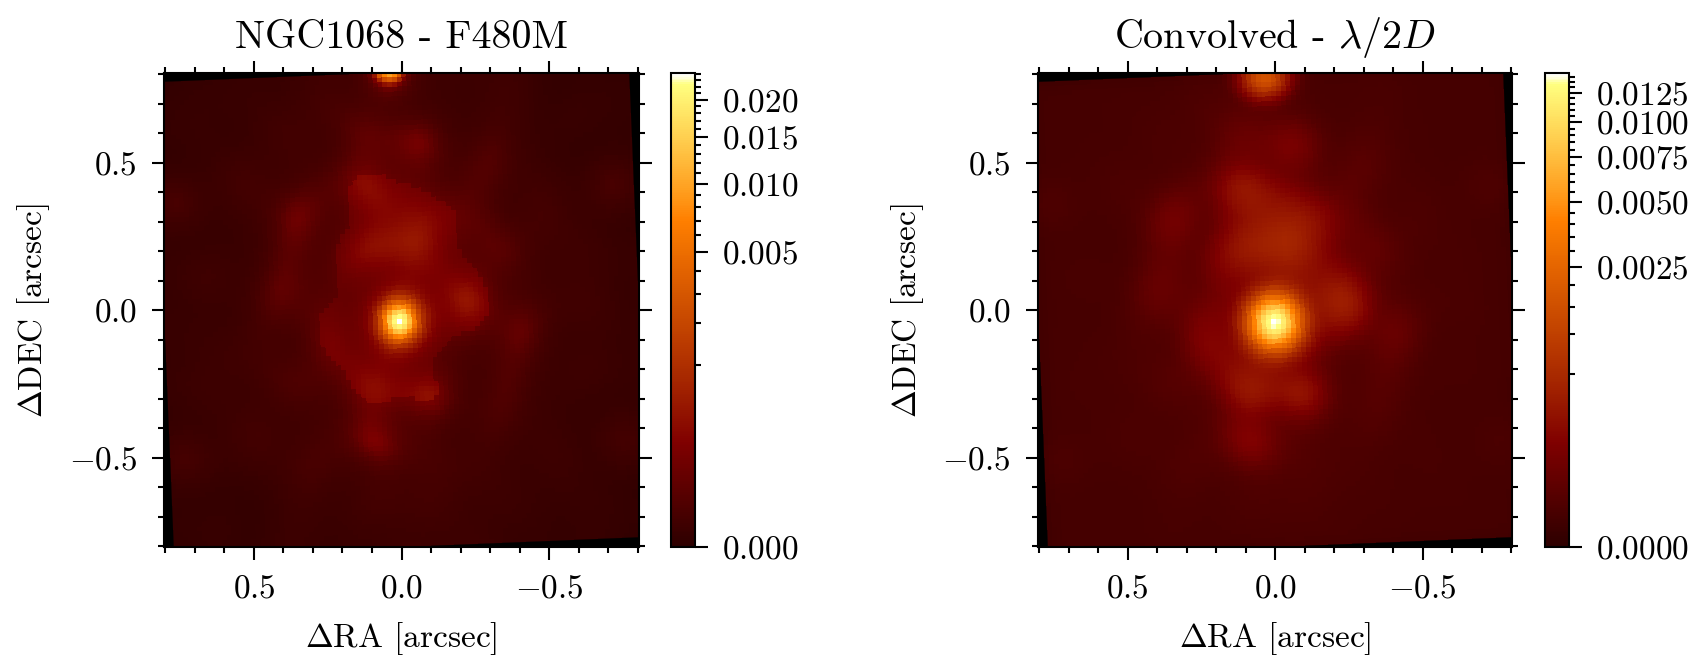

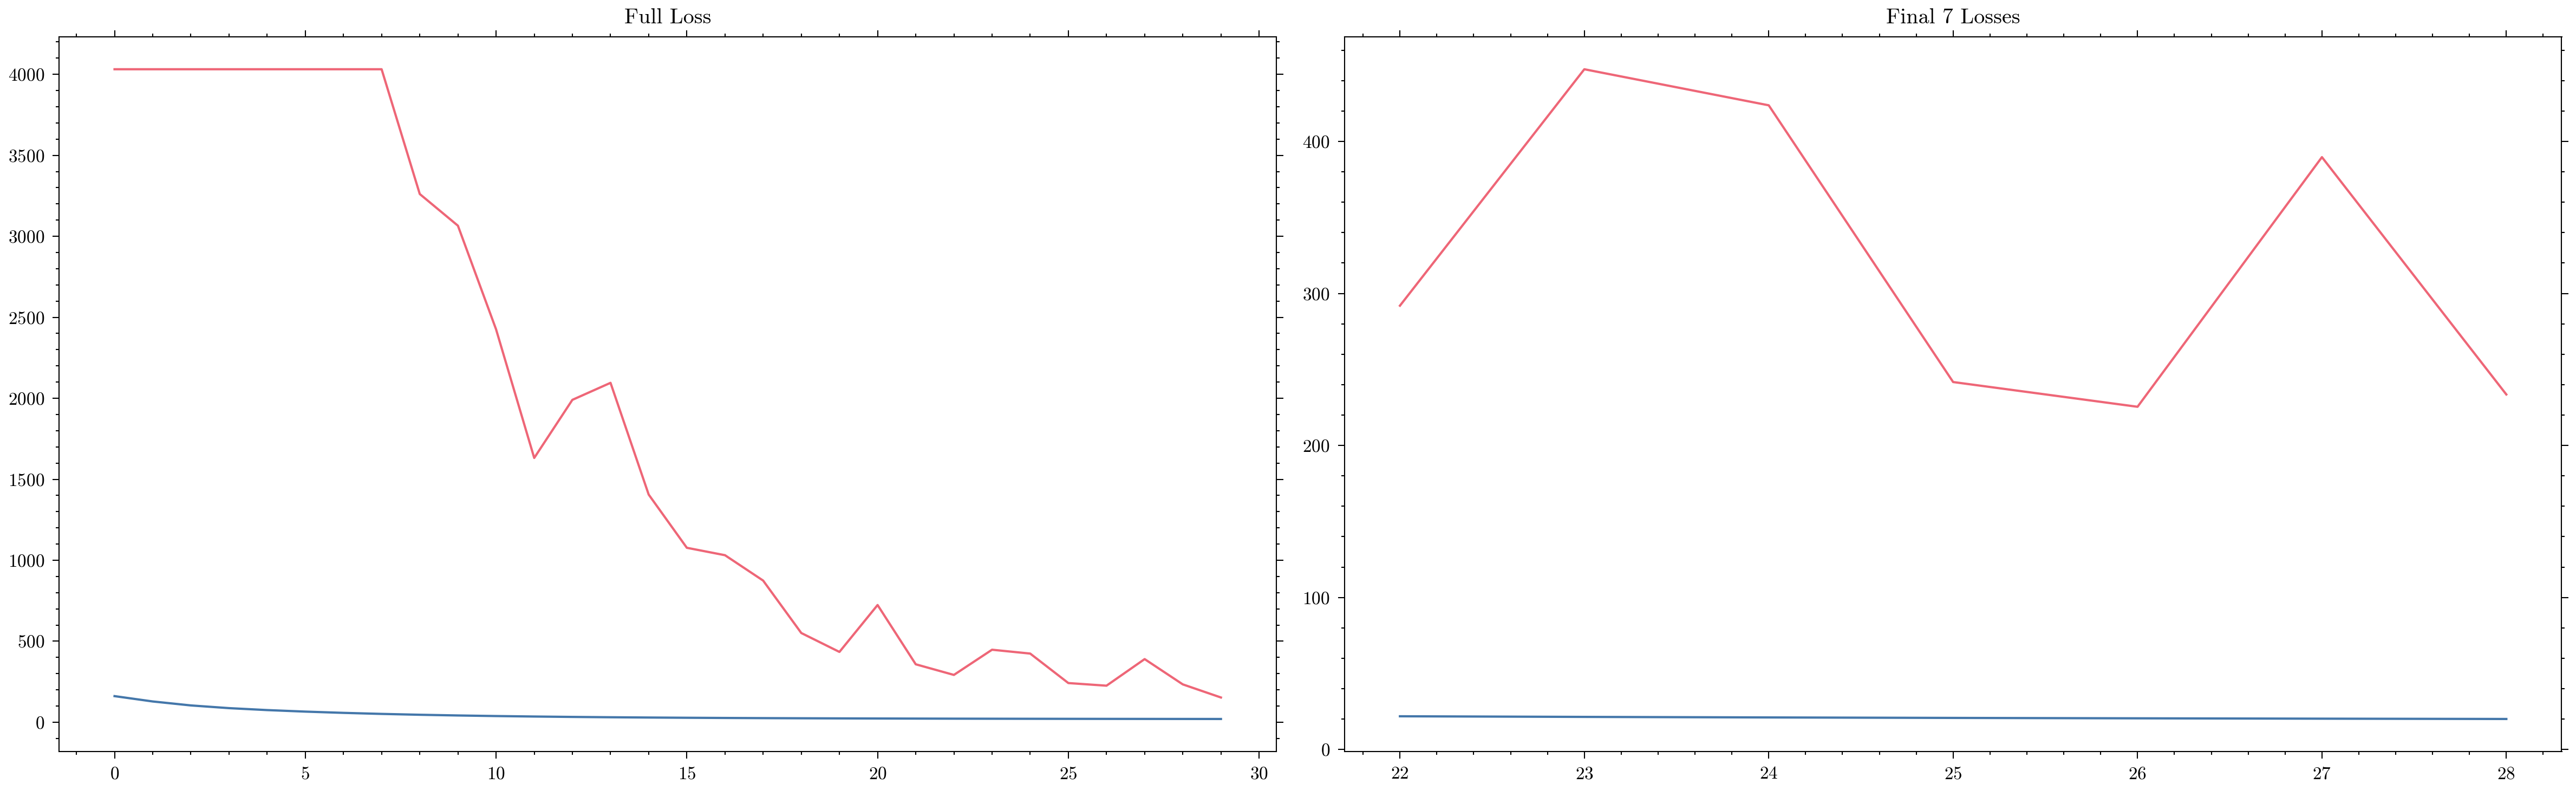

No formatting function for log_distribution


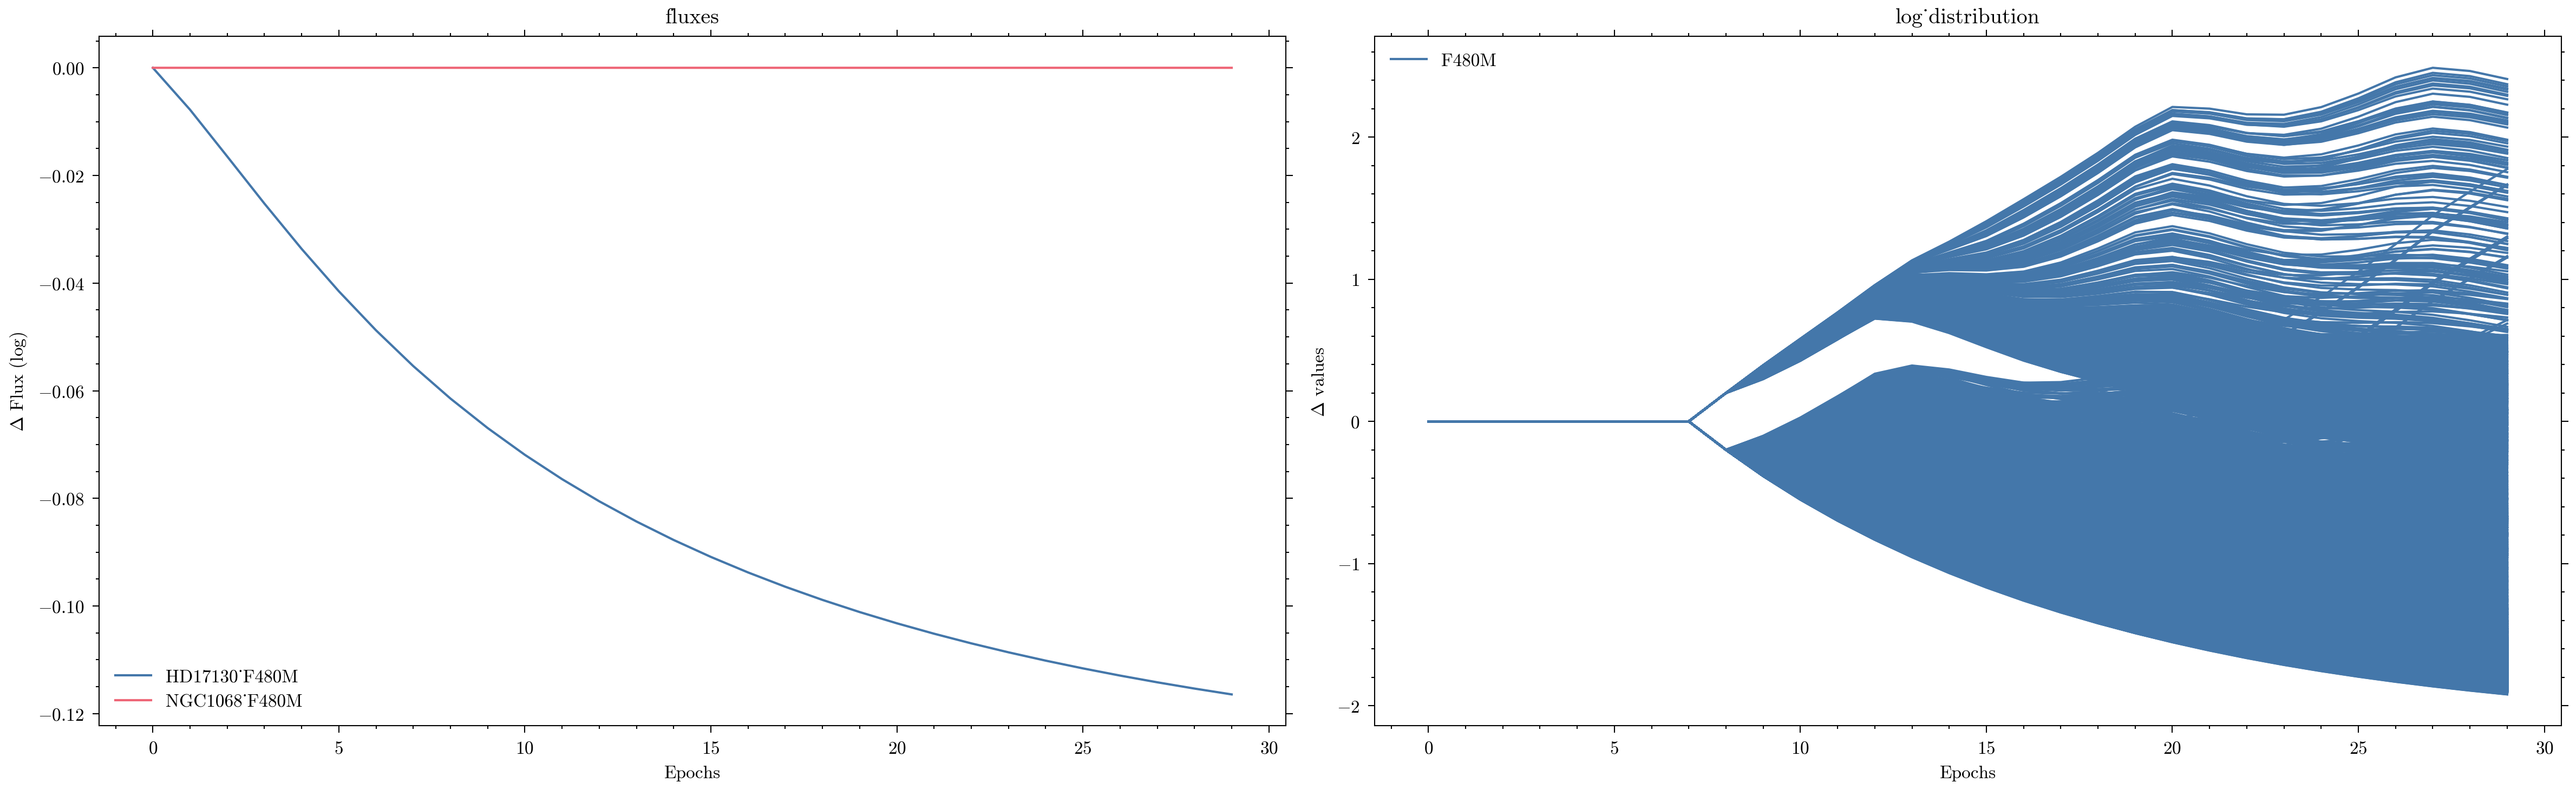

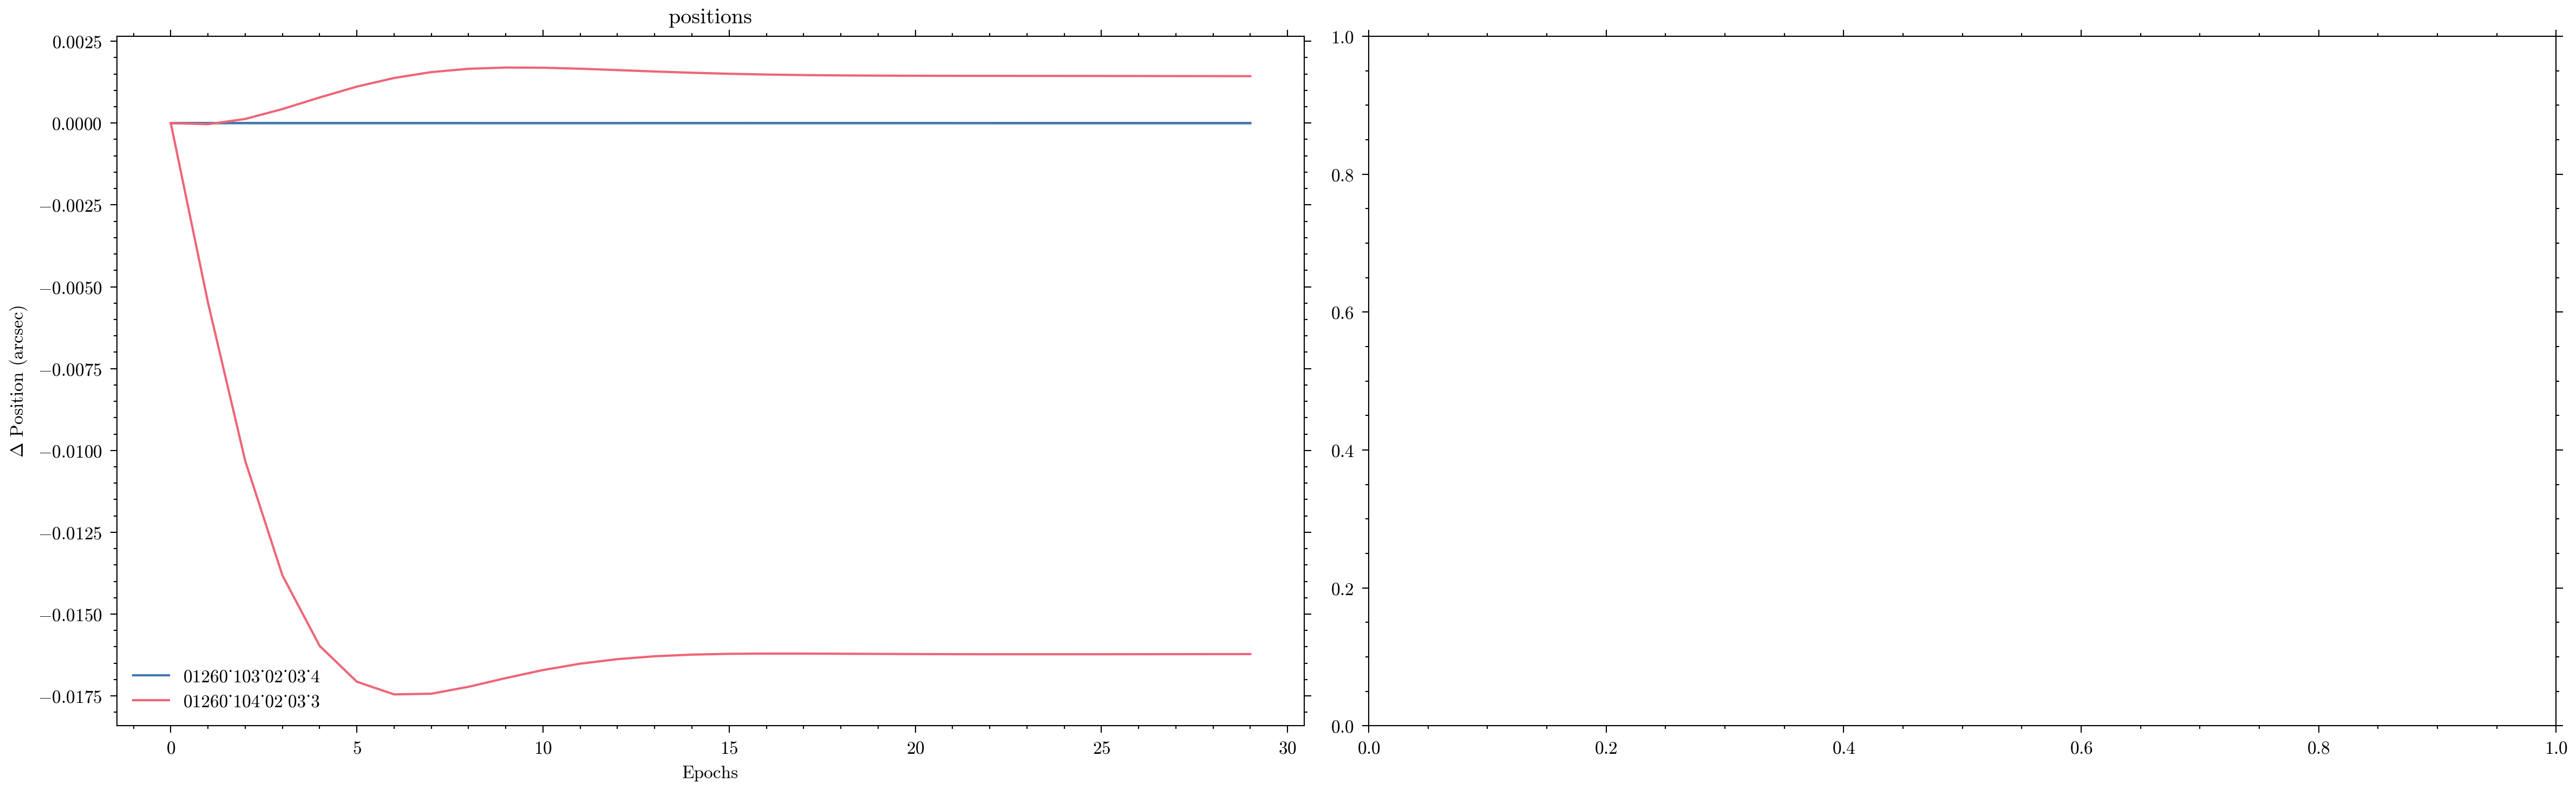

File 01260_104_02_03_3
Star HD17130
Filter F480M
nints 103
ngroups 6



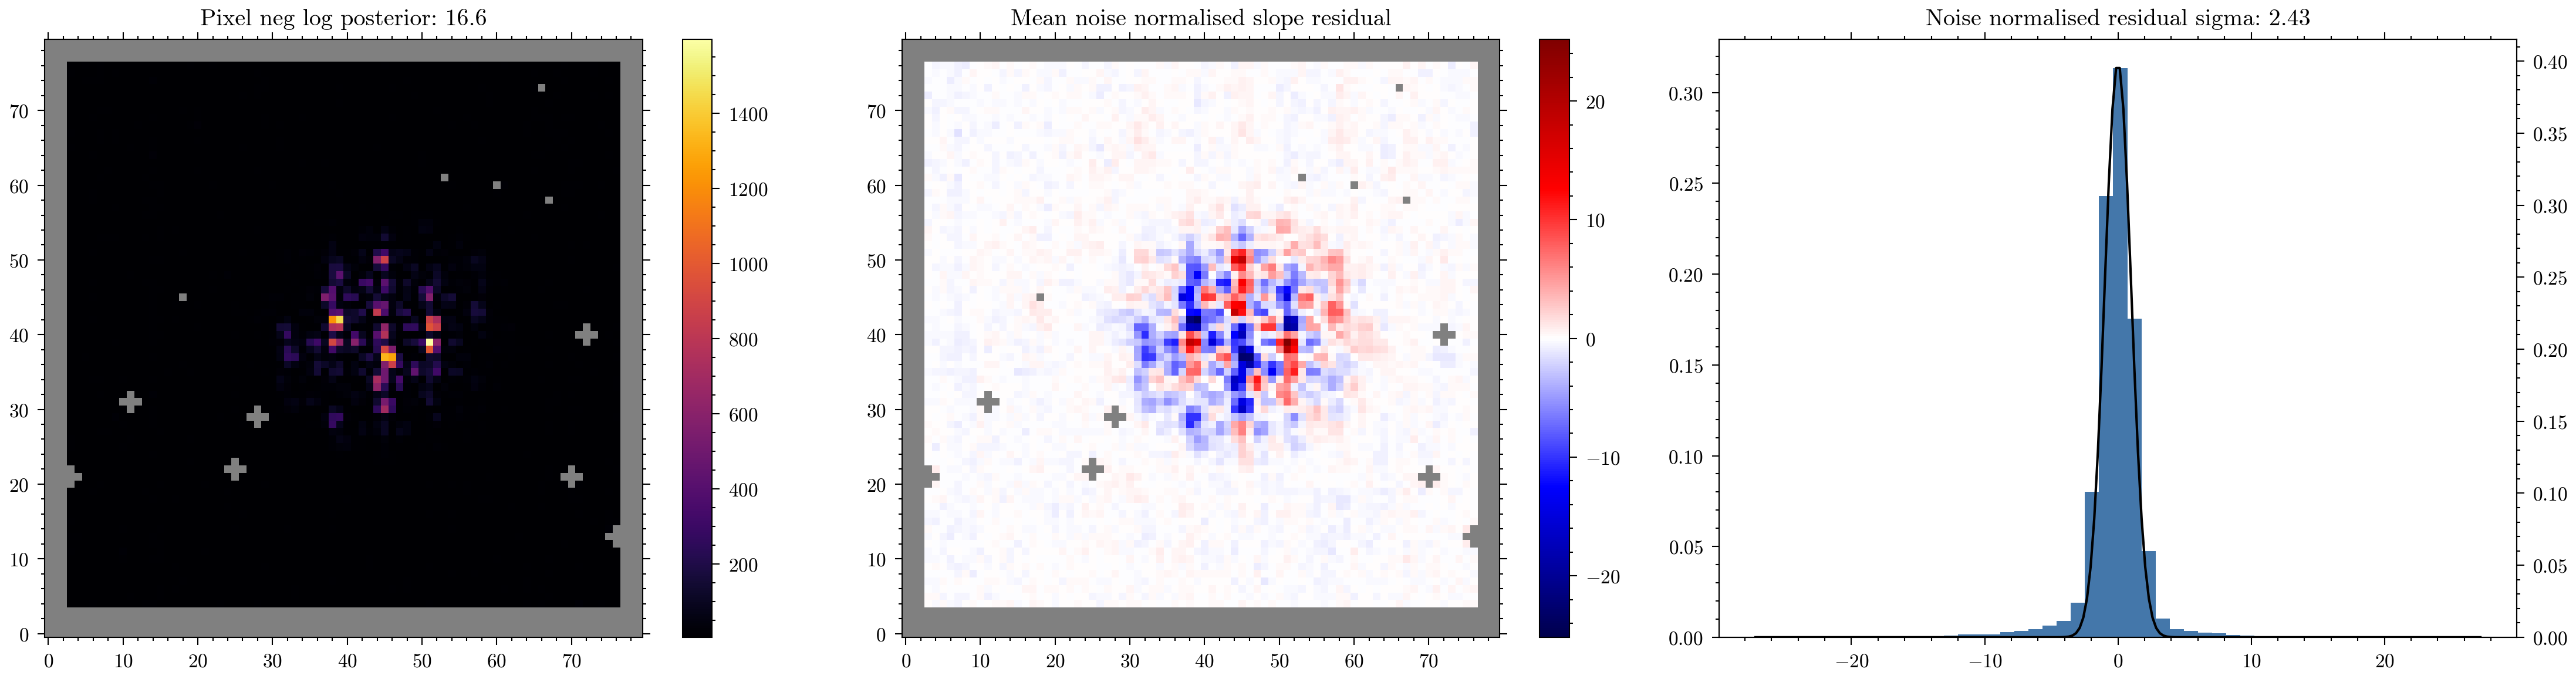

File 01260_103_02_03_4
Star NGC1068
Filter F480M
nints 91
ngroups 3



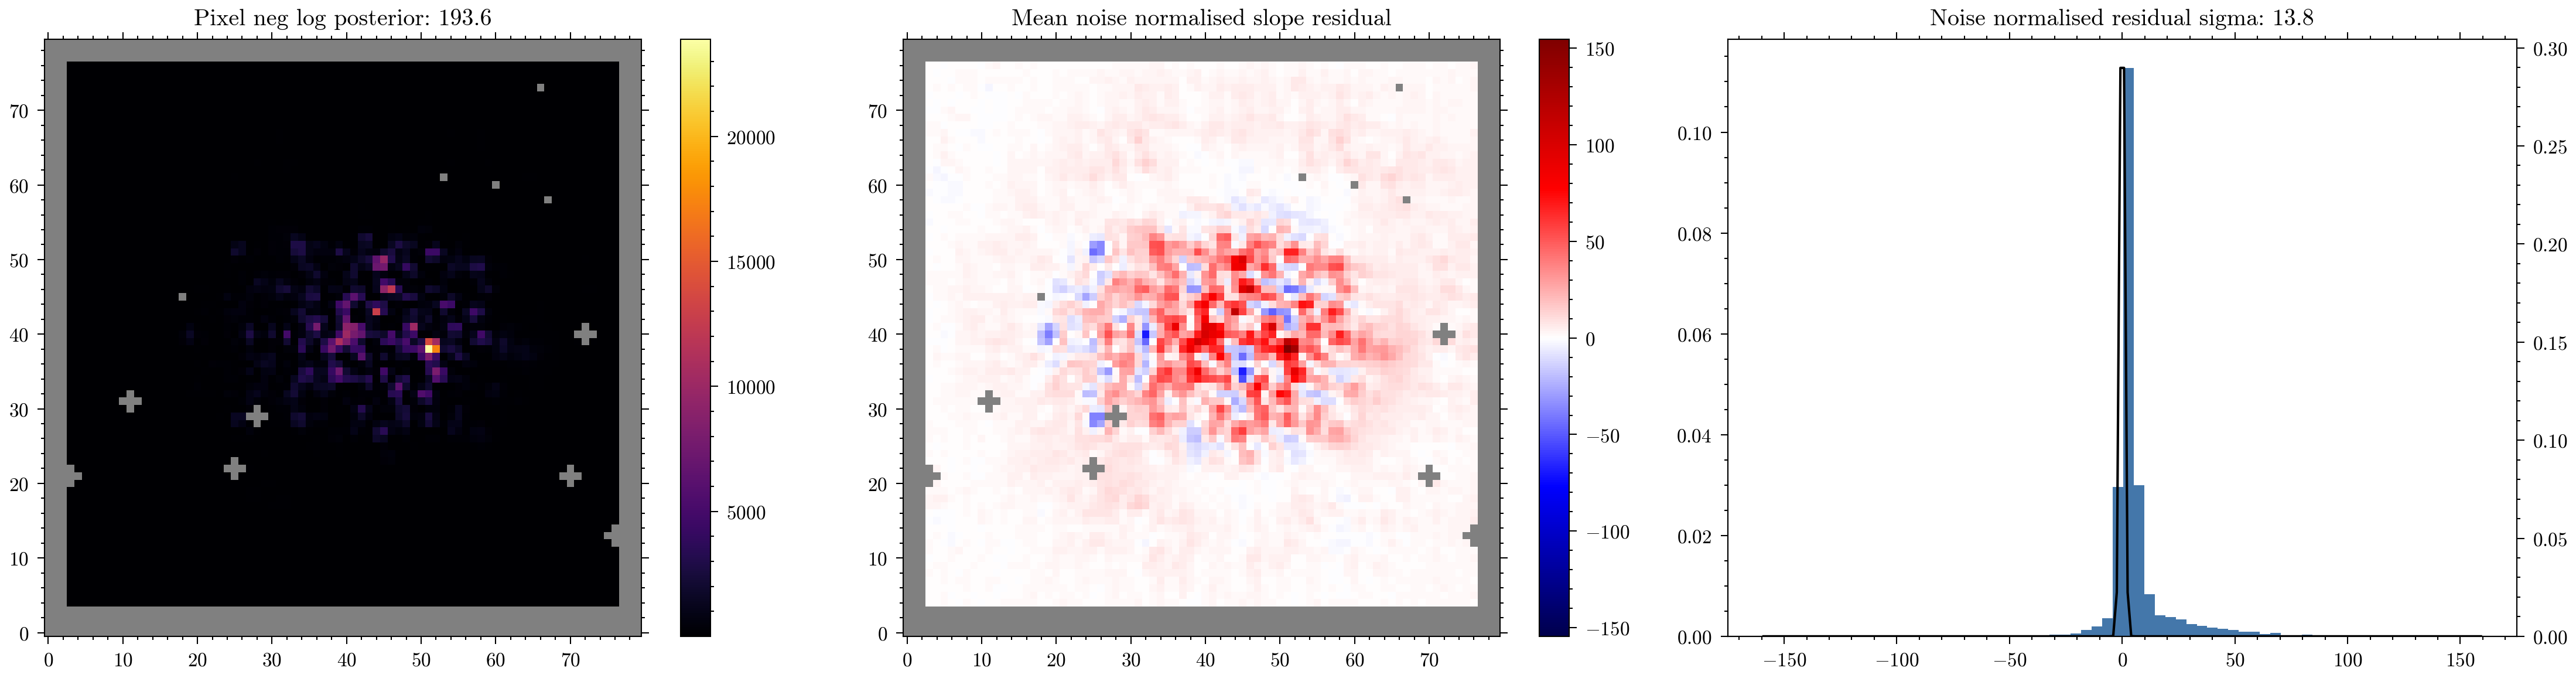

In [13]:
# io_peak_flux = 10 ** np.array(list(io_final_model.log_distribution.values())).max()
# np.save(init_state_cache + "NGC1068/F480Mone.npy", state.params)

for exp in fits:

    try:
        dist = final_model.get_distribution(exp)
    except:
        continue

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))
    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        roll_angle_degrees=-rolls[exp.filename],
        cmap="afmhot_10u",
        power=0.3,
        vmin=None,
        # vmax=io_peak_flux,
    )

    c1 = dorito.plotting.plot_result(
        ax[1],
        dorito.misc.blur_distribution(dist, final_model, exp, factor=0.5),
        cmap="afmhot_10u",
        power=0.3,
        roll_angle_degrees=-rolls[exp.filename],
        # model=hdb_final_model,
    )
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    ax[0].set_title(f"NGC1068 - {exp.filter}")
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(save_dir + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

amigo.plotting.plot_losses(losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(histories)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        final_model,
        exp,
        # test_model,
    )